In [ ]:
import scipy
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer 
from sklearn.linear_model import LinearRegression
import statsmodels.graphics.gofplots as sgg
import statsmodels.graphics.tsaplots as sgt
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
import itertools
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

In [2]:
# Load housing data
housing = pd.read_csv("/media/j/msmj/datasets/housing/housing.csv")

# Encoding 'ocean_proximity' column as numeric values
ocean_mapping = {
    '<1H OCEAN': 1,
    'INLAND': 2,
    'NEAR OCEAN': 3,
    'NEAR BAY': 4,
    'ISLAND': 5
}

housing['ocean_proximity'] = housing['ocean_proximity'].map(ocean_mapping)


# Fill missing values with mean for each column using SimpleImputer
simputer = SimpleImputer(strategy='mean')
housing_ = simputer.fit_transform(housing)

# Convert back to DataFrame
housing = pd.DataFrame(housing_, columns=housing.columns, index=housing.index)

In [3]:
pearson_corr = [
    [f'({i},{j})', scipy.stats.pearsonr(housing[i], housing[j])[0], scipy.stats.pearsonr(housing[i], housing[j])[1]]
    for i in housing.columns for j in housing.columns
]

In [4]:
# H0=data is uncorrelated and normally distributed
# second part of each list is corr and third is p-value 
pearson_corr

[['(longitude,longitude)', 0.9999999999999998, 0.0],
 ['(longitude,latitude)', -0.924664433915041, 0.0],
 ['(longitude,housing_median_age)',
  -0.10819681311244822,
  8.637823911635068e-55],
 ['(longitude,total_rooms)', 0.04456797771665518, 1.4967066668393738e-10],
 ['(longitude,total_bedrooms)', 0.06925966922968511, 2.2433239387246917e-23],
 ['(longitude,population)', 0.09977322287464561, 8.094076049876738e-47],
 ['(longitude,households)', 0.05531009278239543, 1.8381931296609316e-15],
 ['(longitude,median_income)', -0.015175865414173931, 0.0292386665480537],
 ['(longitude,median_house_value)',
  -0.04596661511797853,
  3.9233220710340324e-11],
 ['(longitude,ocean_proximity)', -0.4398704778659949, 0.0],
 ['(latitude,longitude)', -0.924664433915041, 0.0],
 ['(latitude,latitude)', 1.0, 0.0],
 ['(latitude,housing_median_age)', 0.011172673530605394, 0.10847414871210344],
 ['(latitude,total_rooms)', -0.036099595856122824, 2.1294000999640054e-07],
 ['(latitude,total_bedrooms)', -0.0666584173

In [5]:
# Split correlation results
correlated_y = [i for i in pearson_corr[80:90] if i[2] < 0.05]
uncorrelated_y = [i for i in pearson_corr[80:90] if i[2] >= 0.05]

# Output uncorrelated and correlated with 'y'
print('Uncorrelated with y:', uncorrelated_y)
print('\nCorrelated with y:', correlated_y)

Uncorrelated with y: []

Correlated with y: [['(median_house_value,longitude)', -0.045966615117978525, 3.9233220710340324e-11], ['(median_house_value,latitude)', -0.14416027687465927, 2.939859290690422e-96], ['(median_house_value,housing_median_age)', 0.10562341249320993, 2.761860676104524e-52], ['(median_house_value,total_rooms)', 0.13415311380656308, 1.6893845634430203e-83], ['(median_house_value,total_bedrooms)', 0.049453545443227526, 1.1711890792337306e-12], ['(median_house_value,population)', -0.024649678888894896, 0.00039763078478337744], ['(median_house_value,households)', 0.06584265057005646, 2.8234206518994218e-21], ['(median_house_value,median_income)', 0.6880752079585478, 0.0], ['(median_house_value,median_house_value)', 0.9999999999999998, 0.0], ['(median_house_value,ocean_proximity)', 0.021732204251455917, 0.001794046281143069]]


In [6]:
# Analyze feature correlations
features = pearson_corr[:80] + pearson_corr[90:]
correlated_feature = [i for i in features if i[2] < 0.05]
uncorrelated_feature = [i for i in features if i[2] >= 0.05]

# Output correlated and uncorrelated with features
print('Uncorrelated with features:')
for i in uncorrelated_feature:
    print(i)
print('\nCorrelated with features:')
for i in correlated_feature:
    print(i)

Uncorrelated with features:
['(latitude,housing_median_age)', 0.011172673530605394, 0.10847414871210344]
['(housing_median_age,latitude)', 0.011172673530605384, 0.10847414871210344]
['(total_bedrooms,median_income)', -0.007681878004470065, 0.2697769863960701]
['(population,median_income)', 0.004834345627652918, 0.48737218220692874]
['(households,median_income)', 0.013033052400705805, 0.061154565673114995]
['(median_income,total_bedrooms)', -0.007681878004470066, 0.2697769863960701]
['(median_income,population)', 0.004834345627652918, 0.48737218220692874]
['(median_income,households)', 0.013033052400705809, 0.061154565673114995]

Correlated with features:
['(longitude,longitude)', 0.9999999999999998, 0.0]
['(longitude,latitude)', -0.924664433915041, 0.0]
['(longitude,housing_median_age)', -0.10819681311244822, 8.637823911635068e-55]
['(longitude,total_rooms)', 0.04456797771665518, 1.4967066668393738e-10]
['(longitude,total_bedrooms)', 0.06925966922968511, 2.2433239387246917e-23]
['(long

In [7]:
# Drop the target variable 'median_house_value' from features
X_housing = housing.drop(columns='median_house_value')

In [8]:
X_housing.values

array([[-122.23  ,   37.88  ,   41.    , ...,  126.    ,    8.3252,
           4.    ],
       [-122.22  ,   37.86  ,   21.    , ..., 1138.    ,    8.3014,
           4.    ],
       [-122.24  ,   37.85  ,   52.    , ...,  177.    ,    7.2574,
           4.    ],
       ...,
       [-121.22  ,   39.43  ,   17.    , ...,  433.    ,    1.7   ,
           2.    ],
       [-121.32  ,   39.43  ,   18.    , ...,  349.    ,    1.8672,
           2.    ],
       [-121.24  ,   39.37  ,   16.    , ...,  530.    ,    2.3886,
           2.    ]])

In [9]:
# Variance Inflation Factor (VIF) calculation for feature selection
VIF_results = [VIF(X_housing.values, i) for i in range(len(X_housing.columns))]
VIF_df = pd.DataFrame({'variables': X_housing.columns, 'VIF': VIF_results})
VIF_df

,variables,VIF
0,longitude,655.215489
1,latitude,613.628797
2,housing_median_age,7.480625
3,total_rooms,29.142916
4,total_bedrooms,71.902550
5,population,16.371868
6,households,74.472425
7,median_income,8.018322
8,ocean_proximity,5.557059


In [10]:
# Filter features with VIF > 10
new_X_housing = housing[['housing_median_age', 'median_income', 'ocean_proximity']]
new_Y_housing = housing[['median_house_value']]
new_X_housing

,housing_median_age,median_income,ocean_proximity
0,41.0,8.3252,4.0
1,21.0,8.3014,4.0
2,52.0,7.2574,4.0
3,52.0,5.6431,4.0
4,52.0,3.8462,4.0
...,...,...,...
20635,25.0,1.5603,2.0
20636,18.0,2.5568,2.0
20637,17.0,1.7000,2.0
20638,18.0,1.8672,2.0


In [ ]:
# Fit Linear Regression Model using scikit-learn
model = LinearRegression(n_jobs=-1)  # Initialize linear regression model
model.fit(X=new_X_housing, y=new_Y_housing)  # Fit the model to the data

# Use Statsmodels to get the OLS regression summary
X2 = sm.add_constant(new_X_housing)  # Add constant to independent variables for intercept
ols_model = sm.OLS(new_Y_housing, X2).fit()  # Fit OLS model
print(ols_model.summary())  # Print the summary of the OLS model


                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.510
Model:                            OLS   Adj. R-squared:                  0.510
Method:                 Least Squares   F-statistic:                     7149.
Date:                Thu, 27 Mar 2025   Prob (F-statistic):               0.00
Time:                        19:23:51   Log-Likelihood:            -2.6251e+05
No. Observations:               20640   AIC:                         5.250e+05
Df Residuals:                   20636   BIC:                         5.251e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -1.446e+04   2125

In [12]:
# Check residuals
y_hat = model.predict(new_X_housing)
residual = new_Y_housing - y_hat
residual

,median_house_value
0,26636.462383
1,-32148.494134
2,-46591.650454
3,12347.174525
4,90874.439967
...,...
20635,-22945.957512
20636,-54995.011194
20637,-1066.342561
20638,-17603.836255


In [13]:
# Flatten residuals and actual values for further analysis
res_num = residual.values.flatten()
y_num = new_Y_housing.values.flatten()

In [14]:
# Perform Kolmogorov-Smirnov and Shapiro tests on residuals
print(scipy.stats.kstest((res_num - np.mean(res_num)) / np.std(res_num), 'norm'))
print(scipy.stats.kstest(res_num, 'norm'))
print(scipy.stats.shapiro(res_num))

KstestResult(statistic=0.08863791425104917, pvalue=1.5061204710964757e-141, statistic_location=0.15294884130962405, statistic_sign=1)
KstestResult(statistic=0.5824127906863279, pvalue=0.0, statistic_location=-6.687555216776673, statistic_sign=1)
ShapiroResult(statistic=0.9302397840157379, pvalue=1.0184948881685551e-69)


/home/j/miniconda3/envs/sunrise/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20640.
  res = hypotest_fun_out(*samples, **kwds)


/home/j/miniconda3/envs/sunrise/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


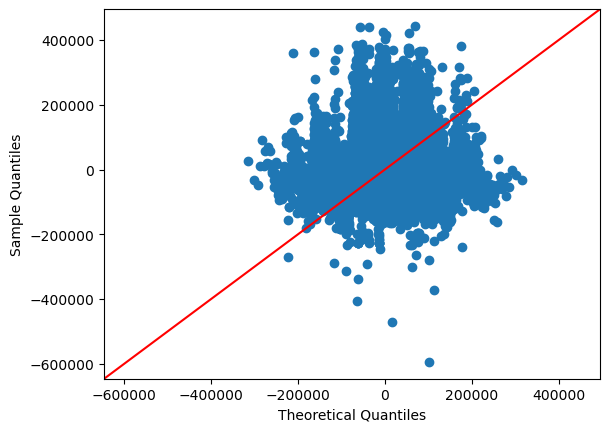

In [15]:
# QQ plot
qqplot=sgg.qqplot(residual,line='45',loc=np.mean(residual),scale=np.std(residual))
plt.show()

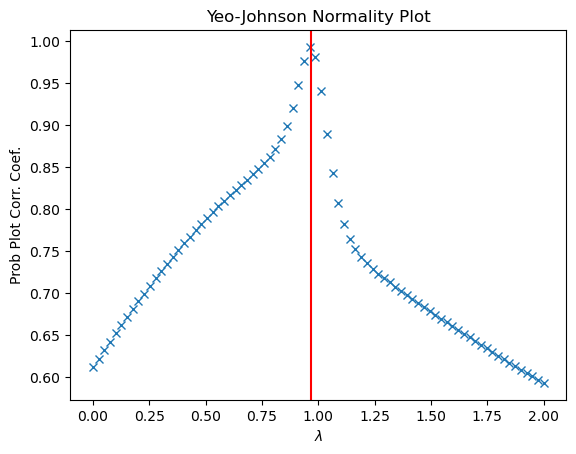

In [16]:
# Yeo-Johnson Transformation for normalization
nm = scipy.stats.yeojohnson_normmax(res_num)
fig, ax = plt.subplots()
scipy.stats.yeojohnson_normplot(res_num, 0, 2, plot=ax)
plt.axvline(nm, color='r')
plt.show()

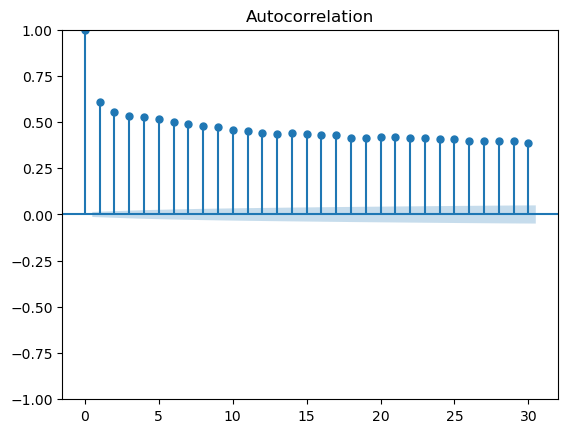

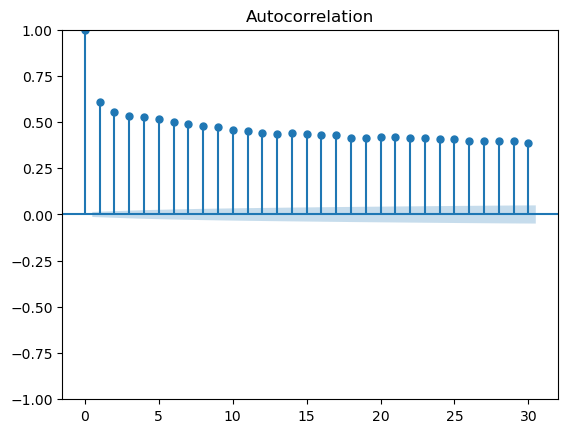

In [17]:
# Check ACF of residuals
sgt.plot_acf(residual, lags=30)

In [ ]:
# Normalize residuals using Yeo-Johnson power transformation
pt = PowerTransformer(method='yeo-johnson').fit(residual)  # Fit Yeo-Johnson transformation
lmbda = pt.lambdas_  # Extract the lambda parameter for the transformation

# Apply Box-Cox transformation to the dependent variable
new_normal_y = scipy.stats.boxcox(y_num)  # Apply Box-Cox transformation
vey_new_normal_y = scipy.stats.boxcox(y_num, lmbda=lmbda)  # Apply Box-Cox with Yeo-Johnson lambda


In [19]:
# Fit new models after transformation
new_model = LinearRegression(n_jobs=-1)
new_model.fit(X=new_X_housing, y=new_normal_y[0])

very_new_model = LinearRegression(n_jobs=-1)
very_new_model.fit(X=new_X_housing, y=vey_new_normal_y)

LinearRegression(n_jobs=-1)

In [ ]:
# Check residuals for new model
new_y_hat = new_model.predict(new_X_housing)  # Predicted values
new_residual = new_normal_y[0] - new_y_hat  # Residuals for new model
print(new_residual)

# Check residuals for the second new model
new_new_y_hat = very_new_model.predict(new_X_housing)  # Predicted values
new_new_residual = vey_new_normal_y - new_new_y_hat  # Residuals for second model
print(new_new_residual)


[-0.09420341 -0.57500684 -0.72704952 ... -0.52556708 -1.06905596
 -1.26141038]
[ 17300.38736379 -21465.01461406 -31073.41088967 ...  -1324.41502011
 -12667.1525647  -22305.094277  ]


In [ ]:
# Kolmogorov-Smirnov and Shapiro tests on transformed residuals

# Test if 'new_residual' follows a normal distribution (standardized and unstandardized)
print(scipy.stats.kstest((new_residual - np.mean(new_residual)) / np.std(new_residual), 'norm'))  # Standardized residuals
print(scipy.stats.kstest(new_residual, np.random.normal(loc=np.mean(new_residual), scale=np.std(new_residual), size=len(new_residual))))  # Unstandardized residuals
print(scipy.stats.shapiro(new_residual))  # Shapiro-Wilk test for normality

print('\n\n')

# Test if 'new_new_residual' follows a normal distribution (standardized and unstandardized)
print(scipy.stats.kstest((new_new_residual - np.mean(new_new_residual)) / np.std(new_new_residual), 'norm'))  # Standardized residuals
print(scipy.stats.kstest(new_new_residual, np.random.normal(loc=np.mean(new_new_residual), scale=np.std(new_new_residual), size=len(new_new_residual))))  # Unstandardized residuals
print(scipy.stats.shapiro(new_new_residual))  # Shapiro-Wilk test for normality


KstestResult(statistic=0.022471294697030353, pvalue=1.741250555970182e-09, statistic_location=0.5248454239266398, statistic_sign=1)
KstestResult(statistic=0.024757751937984462, pvalue=6.2933089047465686e-06, statistic_location=0.7975101360262897, statistic_sign=1)
ShapiroResult(statistic=0.9952429081952562, pvalue=3.8259715190868644e-25)



KstestResult(statistic=0.08602197280420676, pvalue=2.498221810928615e-133, statistic_location=0.15798778215811063, statistic_sign=1)
KstestResult(statistic=0.0859011627906977, pvalue=1.0577694509916541e-66, statistic_location=8618.2497063833, statistic_sign=1)
ShapiroResult(statistic=0.9332725882507353, pvalue=8.594668293666802e-69)


/home/j/miniconda3/envs/sunrise/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20640.
  res = hypotest_fun_out(*samples, **kwds)


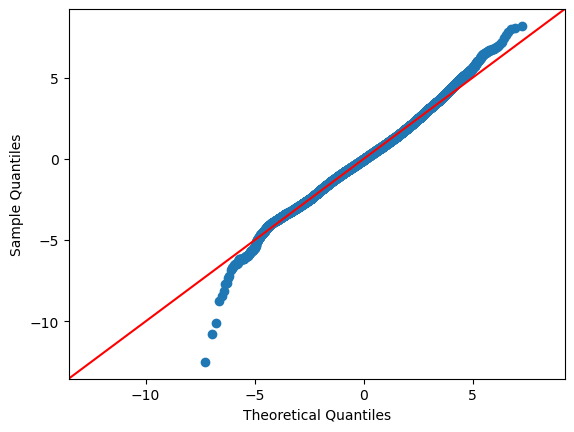

In [22]:
# QQ plot
qqplot=sgg.qqplot(new_residual, line='45', loc=np.mean(new_residual), scale=np.std(new_residual))
plt.show()
# hmmm... better

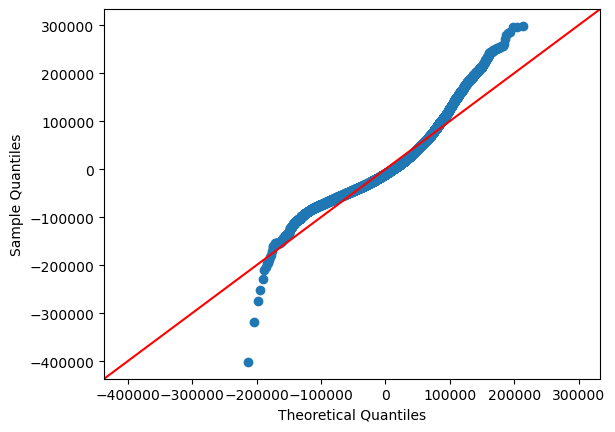

In [23]:
# QQ plot for new_new_residual
qqplot=sgg.qqplot(new_new_residual, line='45', loc=np.mean(new_new_residual), scale=np.std(new_new_residual))
plt.show()


In [ ]:
# Function to fit a linear regression model and return RSS and R-squared
def fit_linear_reg(X, Y):
    model_k = LinearRegression(fit_intercept=True)  # Initialize linear regression model
    model_k.fit(X, Y)  # Fit the model to data
    RSS = mean_squared_error(Y, model_k.predict(X)) * len(Y)  # Calculate Residual Sum of Squares
    R_squared = model_k.score(X, Y)  # Calculate R-squared
    return RSS, R_squared


In [40]:
# Importing tqdm for progress bar
from tqdm.notebook import trange

# Initialization variables
Y = new_normal_y[0]
Y2 = vey_new_normal_y  # Assuming this is a typo, should be `new_normal_y`?
X = new_X_housing

k = 3
RSS_list, R_squared_list, feature_list = [], [], []
numb_features = []

# Looping over feature subsets
for k in trange(1, len(X.columns) + 1, desc='Looping over feature subsets'):
    for combo in itertools.combinations(X.columns, k):
        tmp_result = fit_linear_reg(X[list(combo)], Y)  # Store temp result 
        RSS_list.append(tmp_result[0])  # Append results
        R_squared_list.append(tmp_result[1])
        feature_list.append(combo)
        numb_features.append(len(combo))

# Store results in DataFrame
df = pd.DataFrame({'numb_features': numb_features, 'RSS': RSS_list, 'R_squared': R_squared_list, 'features': feature_list})


Looping over feature subsets:   0%|          | 0/3 [00:00<?, ?it/s]

In [27]:
k = 3
RSS_list2, R_squared_list2, feature_list2 = [],[],[]
numb_features2 = []

#Looping over k = 1 to k = 3 features in X
for k in trange(1,len(X.columns) + 1, desc = 'Loop...'):

    #Looping over all possible combinations: from 3 choose k
    for combo in itertools.combinations(X.columns,k):
        tmp_result2 = fit_linear_reg(X[list(combo)],Y2)   #Store temp result 
        RSS_list2.append(tmp_result2[0])                  #Append lists
        R_squared_list2.append(tmp_result2[1])
        feature_list2.append(combo)
        numb_features2.append(len(combo))   

#Store in DataFrame
df2 = pd.DataFrame({'numb_features': numb_features2,'RSS': RSS_list2, 'R_squared':R_squared_list2,'features':feature_list2})

Loop...:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
# Filter rows where RSS is the minimum and R-squared is the maximum for each 'numb_features' group
df_min = df[df.groupby('numb_features')['RSS'].transform(min) == df['RSS']]
df_max = df[df.groupby('numb_features')['R_squared'].transform(max) == df['R_squared']]

display(df_min)
display(df_max)

print('\n\n')

# Same process for df2
df_min2 = df2[df2.groupby('numb_features')['RSS'].transform(min) == df2['RSS']]
df_max2 = df2[df2.groupby('numb_features')['R_squared'].transform(max) == df2['R_squared']]

display(df_min2)
display(df_max2)


/tmp/ipykernel_271212/3680573087.py:2: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df_min = df[df.groupby('numb_features')['RSS'].transform(min) == df['RSS']]
/tmp/ipykernel_271212/3680573087.py:4: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df_max = df[df.groupby('numb_features')['R_squared'].transform(max) == df['R_squared']]


,numb_features,RSS,R_squared,features,min_RSS,max_R_squared
1,1,75377.799048,0.443671,"(median_income,)",75377.799048,0.443671
3,2,71868.109565,0.469575,"(housing_median_age, median_income)",71868.109565,0.469575
6,3,71863.768804,0.469607,"(housing_median_age, median_income, ocean_prox...",71863.768804,0.469607


,numb_features,RSS,R_squared,features,min_RSS,max_R_squared
1,1,75377.799048,0.443671,"(median_income,)",75377.799048,0.443671
3,2,71868.109565,0.469575,"(housing_median_age, median_income)",71868.109565,0.469575
6,3,71863.768804,0.469607,"(housing_median_age, median_income, ocean_prox...",71863.768804,0.469607


/tmp/ipykernel_271212/3680573087.py:16: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df_min2 = df2[df2.groupby('numb_features')['RSS'].transform(min) == df2['RSS']]
/tmp/ipykernel_271212/3680573087.py:18: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df_max2 = df2[df2.groupby('numb_features')['R_squared'].transform(max) == df2['R_squared']]


,numb_features,RSS,R_squared,features,min_RSS,max_R_squared
1,1,6.616744e+13,0.473510,"(median_income,)",6.616744e+13,0.473510
3,2,6.171669e+13,0.508924,"(housing_median_age, median_income)",6.171669e+13,0.508924
6,3,6.165787e+13,0.509392,"(housing_median_age, median_income, ocean_prox...",6.165787e+13,0.509392


,numb_features,RSS,R_squared,features,min_RSS,max_R_squared
1,1,6.616744e+13,0.473510,"(median_income,)",6.616744e+13,0.473510
3,2,6.171669e+13,0.508924,"(housing_median_age, median_income)",6.171669e+13,0.508924
6,3,6.165787e+13,0.509392,"(housing_median_age, median_income, ocean_prox...",6.165787e+13,0.509392


In [ ]:
# Calculate minimum RSS and maximum R-squared for each feature group in df
df['min_RSS'] = df.groupby('numb_features')['RSS'].transform(min)
df['max_R_squared'] = df.groupby('numb_features')['R_squared'].transform(max)

display(df.head(10))

print('\n\n')

# Repeat the process for df2
df2['min_RSS'] = df2.groupby('numb_features')['RSS'].transform(min)
df2['max_R_squared'] = df2.groupby('numb_features')['R_squared'].transform(max)

display(df2.head(10))


/tmp/ipykernel_271212/3847274298.py:5: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df['min_RSS'] = df.groupby('numb_features')['RSS'].transform(min)  # Calculate minimum RSS for each feature group
/tmp/ipykernel_271212/3847274298.py:6: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df['max_R_squared'] = df.groupby('numb_features')['R_squared'].transform(max)  # Calculate maximum R-squared for each feature group


,numb_features,RSS,R_squared,features,min_RSS,max_R_squared
0,1,134613.144009,0.006483,"(housing_median_age,)",75377.799048,0.443671
1,1,75377.799048,0.443671,"(median_income,)",75377.799048,0.443671
2,1,135479.853540,0.000086,"(ocean_proximity,)",75377.799048,0.443671
3,2,71868.109565,0.469575,"(housing_median_age, median_income)",71868.109565,0.469575
4,2,134552.413176,0.006931,"(housing_median_age, ocean_proximity)",71868.109565,0.469575
5,2,75337.808754,0.443966,"(median_income, ocean_proximity)",71868.109565,0.469575
6,3,71863.768804,0.469607,"(housing_median_age, median_income, ocean_prox...",71863.768804,0.469607


/tmp/ipykernel_271212/3847274298.py:15: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df2['min_RSS'] = df2.groupby('numb_features')['RSS'].transform(min)  # Calculate minimum RSS for each feature group in df2
/tmp/ipykernel_271212/3847274298.py:16: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df2['max_R_squared'] = df2.groupby('numb_features')['R_squared'].transform(max)  # Calculate maximum R-squared for each feature group in df2


,numb_features,RSS,R_squared,features,min_RSS,max_R_squared
0,1,1.242925e+14,0.011012,"(housing_median_age,)",6.616744e+13,0.473510
1,1,6.616744e+13,0.473510,"(median_income,)",6.616744e+13,0.473510
2,1,1.256225e+14,0.000429,"(ocean_proximity,)",6.616744e+13,0.473510
3,2,6.171669e+13,0.508924,"(housing_median_age, median_income)",6.171669e+13,0.508924
4,2,1.242886e+14,0.011043,"(housing_median_age, ocean_proximity)",6.171669e+13,0.508924
5,2,6.587722e+13,0.475819,"(median_income, ocean_proximity)",6.171669e+13,0.508924
6,3,6.165787e+13,0.509392,"(housing_median_age, median_income, ocean_prox...",6.165787e+13,0.509392


/tmp/ipykernel_271212/1951249922.py:2: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df['min_RSS'] = df.groupby('numb_features')['RSS'].transform(min)
/tmp/ipykernel_271212/1951249922.py:3: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df['max_R_squared'] = df.groupby('numb_features')['R_squared'].transform(max)


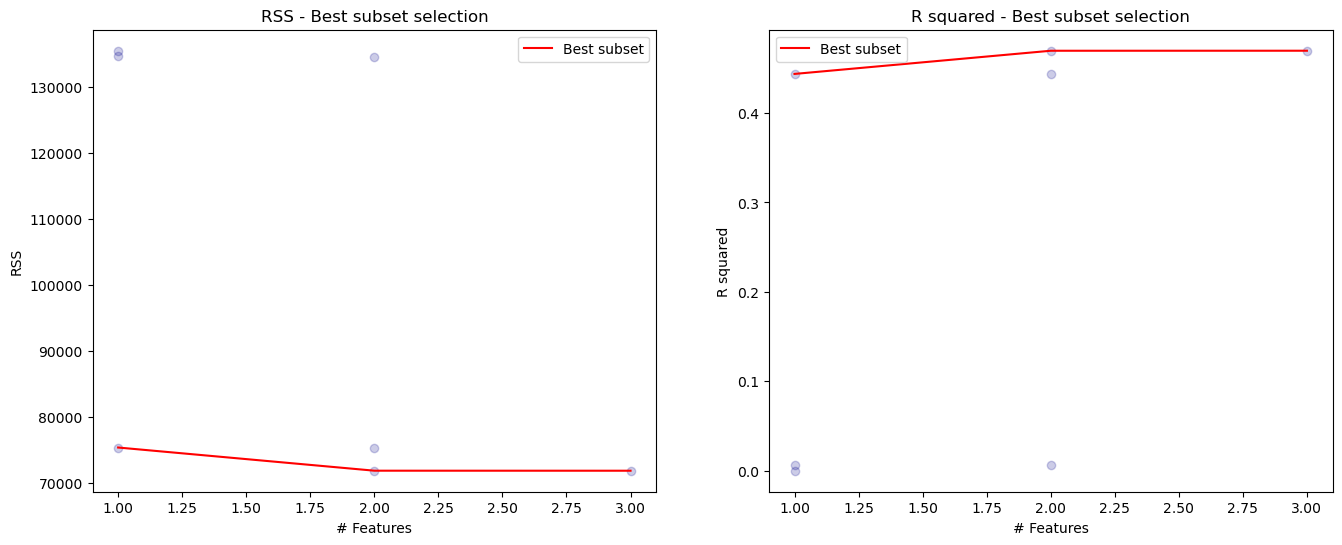

In [36]:
# Ensure that df contains the columns for min RSS and max R-squared for each feature count
df['min_RSS'] = df.groupby('numb_features')['RSS'].transform(min)
df['max_R_squared'] = df.groupby('numb_features')['R_squared'].transform(max)

# Create the figure with two subplots
fig = plt.figure(figsize=(16, 6))

# First subplot: RSS vs. number of features
ax = fig.add_subplot(1, 2, 1)
ax.scatter(df.numb_features, df.RSS, alpha=0.2, color='darkblue')
ax.set_xlabel('# Features')
ax.set_ylabel('RSS')
ax.set_title('RSS - Best subset selection')
ax.plot(df.numb_features, df.min_RSS, color='r', label='Best subset')
ax.legend()

# Second subplot: R-squared vs. number of features
ax = fig.add_subplot(1, 2, 2)
ax.scatter(df.numb_features, df.R_squared, alpha=0.2, color='darkblue')
ax.plot(df.numb_features, df.max_R_squared, color='r', label='Best subset')
ax.set_xlabel('# Features')
ax.set_ylabel('R squared')
ax.set_title('R squared - Best subset selection')
ax.legend()

# Display the plot
plt.show()


/tmp/ipykernel_271212/2319028854.py:2: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df2['min_RSS'] = df2.groupby('numb_features')['RSS'].transform(min)
/tmp/ipykernel_271212/2319028854.py:3: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df2['max_R_squared'] = df2.groupby('numb_features')['R_squared'].transform(max)


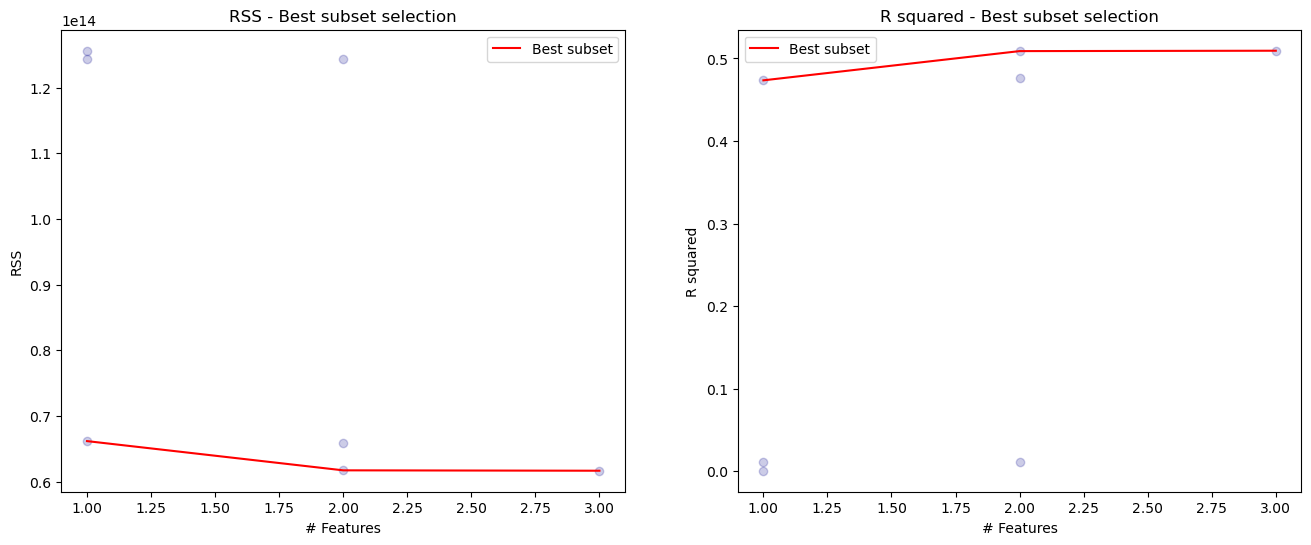

In [34]:
# Ensure that df2 contains the columns for min RSS and max R-squared for each feature count
df2['min_RSS'] = df2.groupby('numb_features')['RSS'].transform(min)
df2['max_R_squared'] = df2.groupby('numb_features')['R_squared'].transform(max)

# Create the figure with two subplots
fig = plt.figure(figsize=(16, 6))

# First subplot: RSS vs. number of features
ax = fig.add_subplot(1, 2, 1)
ax.scatter(df2.numb_features, df2.RSS, alpha=0.2, color='darkblue')
ax.set_xlabel('# Features')
ax.set_ylabel('RSS')
ax.set_title('RSS - Best subset selection')
ax.plot(df2.numb_features, df2.min_RSS, color='r', label='Best subset')
ax.legend()

# Second subplot: R-squared vs. number of features
ax = fig.add_subplot(1, 2, 2)
ax.scatter(df2.numb_features, df2.R_squared, alpha=0.2, color='darkblue')
ax.plot(df2.numb_features, df2.max_R_squared, color='r', label='Best subset')
ax.set_xlabel('# Features')
ax.set_ylabel('R squared')
ax.set_title('R squared - Best subset selection')
ax.legend()

# Display the plot
plt.show()


In [32]:
# (housing_median_age, median_income)
X22 = sm.add_constant(new_X_housing)
est2 = sm.OLS(new_normal_y[0], X22).fit()
print(est2.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     6090.
Date:                Thu, 27 Mar 2025   Prob (F-statistic):               0.00
Time:                        19:24:04   Log-Likelihood:                -42162.
No. Observations:               20640   AIC:                         8.433e+04
Df Residuals:                   20636   BIC:                         8.436e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 23.7743      0

In [33]:
X222 = sm.add_constant(new_X_housing)
est22= sm.OLS(vey_new_normal_y, X222).fit()
print(est22.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     7142.
Date:                Thu, 27 Mar 2025   Prob (F-statistic):               0.00
Time:                        19:24:04   Log-Likelihood:            -2.5444e+05
No. Observations:               20640   AIC:                         5.089e+05
Df Residuals:                   20636   BIC:                         5.089e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -4969.4736   1437